In [3]:
!python -m pip install poetry

In [4]:
# Основные пакеты для INForm проекта
!python -m poetry add numpy pandas matplotlib jupyter ipykernel

The following packages are already present in the pyproject.toml and will be skipped:

  - numpy
  - pandas
  - matplotlib
  - jupyter
  - ipykernel

If you want to update it to the latest compatible version, you can use `poetry update package`.
If you prefer to upgrade it to the latest available version, you can use `poetry add package@latest`.

Nothing to add.


In [5]:
import os
print(f" aktuelles Verzeichnis: {os.getcwd()}")
print(f"\nDateien des Projekts:")
!dir

 aktuelles Verzeichnis: c:\UNI\Meine Programme\INForm_prom\GitHub\Informprojekt_SoSe2026\__Markt-analyse__

Dateien des Projekts:
 Volume in drive C is Local Disk
 Volume Serial Number is C28A-4CED

 Directory of c:\UNI\Meine Programme\INForm_prom\GitHub\Informprojekt_SoSe2026\__Markt-analyse__

16.05.2026  22:47    <DIR>          .
18.05.2026  10:15    <DIR>          ..
15.05.2026  22:57    <DIR>          data
16.05.2026  22:46    <DIR>          Grafiken
18.05.2026  10:23           184�689 Preis_und_Steuern.ipynb
16.05.2026  22:46    <DIR>          Tabakpraevention_in_DE
15.05.2026  22:57    <DIR>          __pycache__
               1 File(s)        184�689 bytes
               6 Dir(s)   8�371�499�008 bytes free


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("Alles funktioniert! 🚀")

Alles funktioniert! 🚀


__Markt-analyse__/
│
├── daten/                    # Папка с вашими 3 Excel-файлами
│   ├── statistic_id37838_durchschnittspreis.xlsx
│   ├── statistic_id377779_packungspreis.xlsx
│   └── statistic_id6213_tabaksteuer.xlsx
│
├── src/                      # Папка с кодом (создайте)
│   ├── __init__.py           # Пустой файл
│   ├── loader.py             # Загрузка данных
│   ├── analyse.py            # Математические расчеты
│   └── plots.py              # Создание графиков
│
├── main.py                   # Главная программа
└── Grafiken/                 # Создастся автоматически

In [7]:
import os
import pandas as pd

# Prüfen, ob die Daten bereits geladen wurden
# Notebook sollte in der Wurzel des Projekts __Markt-analyse__ liegen
daten_path = "daten"  # relativer Pfad

# Prüfen, ob der Ordner existiert
if not os.path.exists(daten_path):
    print(f"Ordner '{daten_path}' nicht gefunden. Suche nach Excel-Dateien im aktuellen Verzeichnis...")
    # Wenn kein Ordner 'daten' vorhanden ist, suchen wir in der aktuellen Verzeichnis
    daten_path = "."

print("\n Suche nach Excel-Dateien...")

# Suchen nach Excel-Dateien in der angegebenen oder aktuellen Verzeichnis
excel_files = [f for f in os.listdir(daten_path) if f.endswith('.xlsx')]

if not excel_files:
    print(" Gibt es keine Excel-Dateien:")
    print(f"   Aktuelles Verzeichnis: {os.getcwd()}")
    print(f"   Inhalt: {os.listdir('.')}")
else:
    print(f"✅ {len(excel_files)} Excel-Dateien gefunden:")
    for f in excel_files:
        print(f"   - {f}")

# Autonomer Datei-Check basierend auf bekannten Schlüsselwörtern und IDs
datei_steuer = None
datei_preis_zig = None
datei_preis_pack = None

for file in excel_files:
    file_lower = file.lower()
    if '6213' in file or 'tabaksteuer' in file_lower:
        datei_steuer = os.path.join(daten_path, file)
        print(f"\n Datei Steuer wurde gefunden: {file}")
    elif '37838' in file or 'durchschnittspreis' in file_lower:
        datei_preis_zig = os.path.join(daten_path, file)
        print(f" Datei Preis Zigarette wurde gefunden: {file}")
    elif '377779' in file or 'schachtel' in file_lower:
        datei_preis_pack = os.path.join(daten_path, file)
        print(f" Datei Preis Packung wurde gefunden: {file}")

# Prüfen, ob alle Dateien gefunden wurden
if not all([datei_steuer, datei_preis_zig, datei_preis_pack]):
    print("\n⚠️ Nicht alle Dateien gefunden:")
    print("   Steuer: statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx")
    print("   Preis Zigarette: statistic_id37838_durchschnittspreis-von-zigaretten-und-enthaltene-tabaksteuer-in-deutschland-bis-2025.xlsx")
    print("   Preis Packung: statistic_id377779_zigaretten_-preis-einer-schachtel-in-deutschland-bis-2026.xlsx")

print("\n" + "="*60)
print("Lade Excel-Dateien...")
print("="*60)

# Wenn Dateien nicht automatisch gefunden wurden, probieren wir standardisierte Namen
if not datei_steuer:
    datei_steuer = os.path.join(daten_path, "statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx")
if not datei_preis_zig:
    datei_preis_zig = os.path.join(daten_path, "statistic_id37838_durchschnittspreis-von-zigaretten-und-enthaltene-tabaksteuer-in-deutschland-bis-2025.xlsx")
if not datei_preis_pack:
    datei_preis_pack = os.path.join(daten_path, "statistic_id377779_zigaretten_-preis-einer-schachtel-in-deutschland-bis-2026.xlsx")

# 1. Steuerdaten
try:
    df_steuer = pd.read_excel(datei_steuer, sheet_name="Daten", skiprows=5)
    jahre_steuer = []
    steuer_mio = []
    for _, row in df_steuer.iterrows():
        try:
            jahr = int(row.iloc[0])
            wert = float(row.iloc[1])
            jahre_steuer.append(jahr)
            steuer_mio.append(wert)
        except:
            pass
    print(f"✓ Steuerdaten: {len(jahre_steuer)} Jahre ({min(jahre_steuer)}-{max(jahre_steuer)})")
except Exception as e:
    print(f"✗ Fehler bei Steuerdaten: {e}")
    jahre_steuer, steuer_mio = [], []

# 2. Preis pro Zigarette
try:
    df_zig = pd.read_excel(datei_preis_zig, sheet_name="Daten", skiprows=5)
    jahre_zig = []
    preis_zig_cent = []
    steuer_zig_cent = []
    for _, row in df_zig.iterrows():
        try:
            jahr = int(row.iloc[0])
            preis = float(row.iloc[1])
            steuer = float(row.iloc[2])
            jahre_zig.append(jahr)
            preis_zig_cent.append(preis)
            steuer_zig_cent.append(steuer)
        except:
            pass
    print(f"✓ Preis Zigarette: {len(jahre_zig)} Jahre ({min(jahre_zig)}-{max(jahre_zig)})")
except Exception as e:
    print(f"✗ Fehler bei Zigarettenpreis: {e}")
    jahre_zig, preis_zig_cent, steuer_zig_cent = [], [], []

# 3. Preis pro Packung
try:
    df_pack = pd.read_excel(datei_preis_pack, sheet_name="Daten", skiprows=5)
    daten = []
    preise_pack_euro = []
    for _, row in df_pack.iterrows():
        try:
            datum = row.iloc[0]
            preis = float(row.iloc[1])
            if isinstance(datum, str):
                jahr = int(datum.split('.')[-1])
            else:
                jahr = int(datum.year)
            daten.append(jahr)
            preise_pack_euro.append(preis)
        except:
            pass
    
    # Gruppiere nach Jahr
    jahre_pack_dict = {}
    for jahr, preis in zip(daten, preise_pack_euro):
        if jahr not in jahre_pack_dict or preis > jahre_pack_dict[jahr]:
            jahre_pack_dict[jahr] = preis
    jahre_pack = sorted(jahre_pack_dict.keys())
    preise_pack_euro = [jahre_pack_dict[j] for j in jahre_pack]
    print(f"✓ Preis Packung: {len(jahre_pack)} Jahre ({min(jahre_pack)}-{max(jahre_pack)})")
except Exception as e:
    print(f"✗ Fehler bei Packungspreis: {e}")
    jahre_pack, preise_pack_euro = [], []

print("\n Daten erfolgreich geladen!")

Ordner 'daten' nicht gefunden. Suche nach Excel-Dateien im aktuellen Verzeichnis...

 Suche nach Excel-Dateien...
 Gibt es keine Excel-Dateien:
   Aktuelles Verzeichnis: c:\UNI\Meine Programme\INForm_prom\GitHub\Informprojekt_SoSe2026\__Markt-analyse__
   Inhalt: ['data', 'Grafiken', 'Preis_und_Steuern.ipynb', 'Tabakpraevention_in_DE', '__pycache__']

⚠️ Nicht alle Dateien gefunden:
   Steuer: statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx
   Preis Zigarette: statistic_id37838_durchschnittspreis-von-zigaretten-und-enthaltene-tabaksteuer-in-deutschland-bis-2025.xlsx
   Preis Packung: statistic_id377779_zigaretten_-preis-einer-schachtel-in-deutschland-bis-2026.xlsx

Lade Excel-Dateien...
✗ Fehler bei Steuerdaten: [Errno 2] No such file or directory: '.\\statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx'
✗ Fehler bei Zigarettenpreis: [Errno 2] No such file or directory: '.\\statistic_id37838_durchschnittspr

In [8]:
import os

print("="*60)
print("SUCHE NACH EXCEL-DATEIEN")
print("="*60)

# Aktuelle Verzeichnisse
current_dir = os.getcwd()
print(f"\nAktuelles Verzeichnis: {current_dir}")

# Suche in aktueller Ordner
print(f"\nDateien im aktuellen Ordner:")
if os.path.exists(current_dir):
    files = os.listdir(current_dir)
    excel_files = [f for f in files if f.endswith('.xlsx')]
    if excel_files:
        print(f"  Gefundene Excel-Dateien ({len(excel_files)}):")
        for f in excel_files:
            print(f"    - {f}")
    else:
        print("  Keine Excel-Dateien gefunden")
    print(f"\n  Alle Dateien: {files[:10]}")  # Zeige erste 10 Dateien

# Suche in Unterordner 'daten'
daten_path = os.path.join(current_dir, "daten")
print(f"\nPrüfe Ordner: {daten_path}")
if os.path.exists(daten_path):
    print(f"  Ordner 'daten' existiert")
    files = os.listdir(daten_path)
    excel_files = [f for f in files if f.endswith('.xlsx')]
    if excel_files:
        print(f"  Gefundene Excel-Dateien ({len(excel_files)}):")
        for f in excel_files:
            print(f"    - {f}")
    else:
        print("  Keine Excel-Dateien im 'daten' Ordner")
else:
    print("  Ordner 'daten' existiert NICHT")

# Suche im übergeordneten Ordner
parent_dir = os.path.dirname(current_dir)
print(f"\nPrüfe übergeordneten Ordner: {parent_dir}")
if os.path.exists(parent_dir):
    files = os.listdir(parent_dir)
    excel_files = [f for f in files if f.endswith('.xlsx')]
    if excel_files:
        print(f"  Gefundene Excel-Dateien ({len(excel_files)}):")
        for f in excel_files:
            print(f"    - {f}")

SUCHE NACH EXCEL-DATEIEN

Aktuelles Verzeichnis: c:\UNI\Meine Programme\INForm_prom\GitHub\Informprojekt_SoSe2026\__Markt-analyse__

Dateien im aktuellen Ordner:
  Keine Excel-Dateien gefunden

  Alle Dateien: ['data', 'Grafiken', 'Preis_und_Steuern.ipynb', 'Tabakpraevention_in_DE', '__pycache__']

Prüfe Ordner: c:\UNI\Meine Programme\INForm_prom\GitHub\Informprojekt_SoSe2026\__Markt-analyse__\daten
  Ordner 'daten' existiert NICHT

Prüfe übergeordneten Ordner: c:\UNI\Meine Programme\INForm_prom\GitHub\Informprojekt_SoSe2026


In [9]:
import os
import pandas as pd

print("="*60)
print("Lade Excel-Dateien aus Ordner 'data'")
print("="*60)

# Используем существующую папку 'data'
daten_path = "data"  # <-- используем data вместо daten
    # Показываем все Excel файлы
excel_files = [f for f in os.listdir(daten_path) if f.endswith('.xlsx')]
print(f"\n📁 Найдено Excel файлов: {len(excel_files)}")
for f in excel_files:
    print(f"   - {f}")

print("\n" + "="*60)
print("Lade Daten...")
print("="*60)

# Автоматически находим файлы в папке data
datei_steuer = None
datei_preis_zig = None
datei_preis_pack = None

for file in os.listdir(daten_path):
    if file.endswith('.xlsx'):
        file_lower = file.lower()
        if '6213' in file or 'steuerwerte' in file_lower or 'tabaksteuer' in file_lower:
            datei_steuer = os.path.join(daten_path, file)
            print(f"✓ Steuerdatei: {file}")
        elif '37838' in file or 'durchschnittspreis' in file_lower:
            datei_preis_zig = os.path.join(daten_path, file)
            print(f"✓ Preis Zigarette: {file}")
        elif '377779' in file or 'schachtel' in file_lower:
            datei_preis_pack = os.path.join(daten_path, file)
            print(f"✓ Preis Packung: {file}")

# Если не нашли по ключевым словам, берем все файлы по порядку
if not datei_steuer and excel_files:
    datei_steuer = os.path.join(daten_path, excel_files[0])
    print(f"⚠️ Steuerdatei nicht erkannt, verwende: {excel_files[0]}")
if not datei_preis_zig and len(excel_files) > 1:
    datei_preis_zig = os.path.join(daten_path, excel_files[1])
    print(f"⚠️ Preis Zigarette nicht erkannt, verwende: {excel_files[1]}")
if not datei_preis_pack and len(excel_files) > 2:
    datei_preis_pack = os.path.join(daten_path, excel_files[2])
    print(f"⚠️ Preis Packung nicht erkannt, verwende: {excel_files[2]}")

# 1. Steuerdaten
try:
    df_steuer = pd.read_excel(datei_steuer, sheet_name="Daten", skiprows=5)
    jahre_steuer = []
    steuer_mio = []
    for _, row in df_steuer.iterrows():
        try:
            jahr = int(row.iloc[0])
            wert = float(row.iloc[1])
            jahre_steuer.append(jahr)
            steuer_mio.append(wert)
        except:
            pass
    print(f"✓ Steuerdaten: {len(jahre_steuer)} Jahre ({min(jahre_steuer)}-{max(jahre_steuer)})")
except Exception as e:
    print(f"✗ Fehler bei Steuerdaten: {e}")
    jahre_steuer, steuer_mio = [], []

# 2. Preis pro Zigarette
try:
    df_zig = pd.read_excel(datei_preis_zig, sheet_name="Daten", skiprows=5)
    jahre_zig = []
    preis_zig_cent = []
    steuer_zig_cent = []
    for _, row in df_zig.iterrows():
        try:
            jahr = int(row.iloc[0])
            preis = float(row.iloc[1])
            steuer = float(row.iloc[2])
            jahre_zig.append(jahr)
            preis_zig_cent.append(preis)
            steuer_zig_cent.append(steuer)
        except:
            pass
    print(f"✓ Preis Zigarette: {len(jahre_zig)} Jahre ({min(jahre_zig)}-{max(jahre_zig)})")
except Exception as e:
    print(f"✗ Fehler bei Zigarettenpreis: {e}")
    jahre_zig, preis_zig_cent, steuer_zig_cent = [], [], []

# 3. Preis pro Packung
try:
    df_pack = pd.read_excel(datei_preis_pack, sheet_name="Daten", skiprows=5)
    daten = []
    preise_pack_euro = []
    for _, row in df_pack.iterrows():
        try:
            datum = row.iloc[0]
            preis = float(row.iloc[1])
            if isinstance(datum, str):
                jahr = int(datum.split('.')[-1])
            else:
                jahr = int(datum.year)
            daten.append(jahr)
            preise_pack_euro.append(preis)
        except:
            pass
    
    # Gruppiere nach Jahr
    jahre_pack_dict = {}
    for jahr, preis in zip(daten, preise_pack_euro):
        if jahr not in jahre_pack_dict or preis > jahre_pack_dict[jahr]:
            jahre_pack_dict[jahr] = preis
    jahre_pack = sorted(jahre_pack_dict.keys())
    preise_pack_euro = [jahre_pack_dict[j] for j in jahre_pack]
    print(f"✓ Preis Packung: {len(jahre_pack)} Jahre ({min(jahre_pack)}-{max(jahre_pack)})")
except Exception as e:
    print(f"✗ Fehler bei Packungspreis: {e}")
    jahre_pack, preise_pack_euro = [], []

print("\n" + "="*60)
print("✅ Daten geladen!")
print(f"  Steuerdaten: {len(jahre_steuer)} Jahre")
print(f"  Preis Zigarette: {len(jahre_zig)} Jahre")
print(f"  Preis Packung: {len(jahre_pack)} Jahre")
print("="*60)

Lade Excel-Dateien aus Ordner 'data'

📁 Найдено Excel файлов: 3
   - statistic_id377779_zigaretten_-preis-einer-schachtel-in-deutschland-bis-2026.xlsx
   - statistic_id37838_durchschnittspreis-von-zigaretten-und-enthaltene-tabaksteuer-in-deutschland-bis-2025.xlsx
   - statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx

Lade Daten...
✓ Preis Packung: statistic_id377779_zigaretten_-preis-einer-schachtel-in-deutschland-bis-2026.xlsx
✓ Steuerdatei: statistic_id37838_durchschnittspreis-von-zigaretten-und-enthaltene-tabaksteuer-in-deutschland-bis-2025.xlsx
✓ Steuerdatei: statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx
⚠️ Preis Zigarette nicht erkannt, verwende: statistic_id37838_durchschnittspreis-von-zigaretten-und-enthaltene-tabaksteuer-in-deutschland-bis-2025.xlsx
✗ Fehler bei Steuerdaten: min() iterable argument is empty
✗ Fehler bei Zigarettenpreis: min() iterable argument is empty
✗ Fehler bei Packungsprei

In [10]:
import pandas as pd
import os

print("="*60)
print("АНАЛИЗ СТРУКТУРЫ EXCEL ФАЙЛОВ")
print("="*60)

# Папка с данными
daten_path = "data"

# Файлы
files = {
    'Steuer': 'statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx',
    'Preis Zigarette': 'statistic_id37838_durchschnittspreis-von-zigaretten-und-enthaltene-tabaksteuer-in-deutschland-bis-2025.xlsx',
    'Preis Packung': 'statistic_id377779_zigaretten_-preis-einer-schachtel-in-deutschland-bis-2026.xlsx'
}

for name, filename in files.items():
    print(f"\n{'='*60}")
    print(f"Файл: {name}")
    print(f"{'='*60}")
    
    filepath = os.path.join(daten_path, filename)
    
    try:
        # Читаем первые 15 строк без пропусков
        df_raw = pd.read_excel(filepath, sheet_name="Daten", header=None, nrows=15)
        print("\nПервые 15 строк файла:")
        print(df_raw.to_string())
        
        # Также проверим название листов
        xl = pd.ExcelFile(filepath)
        print(f"\nДоступные листы: {xl.sheet_names}")
        
    except Exception as e:
        print(f"Ошибка: {e}")

АНАЛИЗ СТРУКТУРЫ EXCEL ФАЙЛОВ

Файл: Steuer

Первые 15 строк файла:
     0                                                                                                          1         2
0  NaN                                                                                                        NaN       NaN
1  NaN                                                                                                        NaN       NaN
2  NaN                                         Steuerwerte der Tabaksteuer für Zigaretten in Deutschland bis 2025       NaN
3  NaN  Steuerwerte der Tabaksteuer für Zigaretten in Deutschland in den Jahren 1980 bis 2025 (in Millionen Euro)       NaN
4  NaN                                                                                                        NaN       NaN
5  NaN                                                                                                       2025  13105.00
6  NaN                                                          

In [11]:
import os
import pandas as pd

print("="*60)
print("Lade Excel-Dateien (FINAL KORRIGIERTE VERSION)")
print("="*60)

daten_path = "data"

# Файлы
file_steuer = os.path.join(daten_path, "statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx")
file_preis_zig = os.path.join(daten_path, "statistic_id37838_durchschnittspreis-von-zigaretten-und-enthaltene-tabaksteuer-in-deutschland-bis-2025.xlsx")
file_preis_pack = os.path.join(daten_path, "statistic_id377779_zigaretten_-preis-einer-schachtel-in-deutschland-bis-2026.xlsx")

# 1. STEUERDATEN
print("\n1. Lade Steuerdaten...")
try:
    # Die Daten beginnen mit 5 Zeilen (index 5)
    df_steuer = pd.read_excel(file_steuer, sheet_name="Daten", header=None, skiprows=5)
    
    jahre_steuer = []
    steuer_mio = []
    
    for _, row in df_steuer.iterrows():
        try:
            jahr = int(row[0])
            wert = float(row[1])
            jahre_steuer.append(jahr)
            steuer_mio.append(wert)
        except:
            pass
    
    print(f"   ✓ Geladen: {len(jahre_steuer)} Jahre ({min(jahre_steuer)}-{max(jahre_steuer)})")
    print(f"   Beispiel: {jahre_steuer[0]} = {steuer_mio[0]} Mio. Euro")
except Exception as e:
    print(f"   ✗ Fehler: {e}")
    jahre_steuer, steuer_mio = [], []

# 2. PREIS PRO ZIGARETTE
print("\n2. Lade Preis pro Zigarette...")
try:
    # Die Daten beginnen mit 5 Zeilen (index 5)
    df_zig = pd.read_excel(file_preis_zig, sheet_name="Daten", header=None, skiprows=5)
    
    jahre_zig = []
    preis_zig_cent = []
    steuer_zig_cent = []
    
    for _, row in df_zig.iterrows():
        try:
            jahr = int(row[1])  
            preis = float(row[2])  
            steuer = float(row[3])
            jahre_zig.append(jahr)
            preis_zig_cent.append(preis)
            steuer_zig_cent.append(steuer)
        except Exception as e:
            pass
    
    print(f"   ✓ Geladen: {len(jahre_zig)} Jahre ({min(jahre_zig)}-{max(jahre_zig)})")
    print(f"   Beispiel: {jahre_zig[0]} = {preis_zig_cent[0]} Cent, Steuer: {steuer_zig_cent[0]} Cent")
except Exception as e:
    print(f"   ✗ Fehler: {e}")
    jahre_zig, preis_zig_cent, steuer_zig_cent = [], [], []

# 3. PREIS PRO PACKUNG
print("\n3. Lade Preis pro Packung...")
try:
    # Данные начинаются с 5 строки (индекс 5)
    df_pack = pd.read_excel(file_preis_pack, sheet_name="Daten", header=None, skiprows=5)
    
    daten = []
    preise_pack_euro = []
    
    for _, row in df_pack.iterrows():
        try:
            datum = str(row[1])  # Datum in 1. Spalte
            preis = float(row[2])  # Preis in 2. Spalte
            
            # Extrahieren ein Jahr
            if '.' in datum:
                jahr = int(datum.split('.')[-1])
            else:
                jahr = int(datum[:4])
            
            daten.append(jahr)
            preise_pack_euro.append(preis)
        except:
            pass
    
    # Wir gruppieren nach Jahr (wir nehmen den letzten Preis des Jahres)
    jahre_pack_dict = {}
    for jahr, preis in zip(daten, preise_pack_euro):
        if jahr not in jahre_pack_dict or preis > jahre_pack_dict[jahr]:
            jahre_pack_dict[jahr] = preis
    
    jahre_pack = sorted(jahre_pack_dict.keys())
    preise_pack_euro = [jahre_pack_dict[j] for j in jahre_pack]
    
    print(f"   Geladen: {len(jahre_pack)} Jahre ({min(jahre_pack)}-{max(jahre_pack)})")
    print(f"   Beispiel: {jahre_pack[0]} = {preise_pack_euro[0]} Euro")
except Exception as e:
    print(f"   ✗ Fehler: {e}")
    jahre_pack, preise_pack_euro = [], []

print("\n" + "="*60)
print(f"Fazit von Daten:")
print(f"  Steuerdaten: {len(jahre_steuer)} Jahre")
print(f"  Preis Zigarette: {len(jahre_zig)} Jahre")
print(f"  Preis Packung: {len(jahre_pack)} Jahre")
print("="*60)


"""
# Lassen Sie uns die ersten 5 Werte zur Überprüfung anzeigen
if jahre_zig:
    print("\n📊 Пример данных (Preis pro Zigarette):")
    for i in range(min(5, len(jahre_zig))):
        print(f"  {jahre_zig[i]}: {preis_zig_cent[i]:.2f} Cent | Steuer: {steuer_zig_cent[i]:.2f} Cent")

if jahre_steuer:
    print("\n Daten Bespiel(Steuereinnahmen):")
    for i in range(min(5, len(jahre_steuer))):
        print(f"  {jahre_steuer[i]}: {steuer_mio[i]:.2f} Mio. Euro")"""

Lade Excel-Dateien (FINAL KORRIGIERTE VERSION)

1. Lade Steuerdaten...
   ✗ Fehler: min() iterable argument is empty

2. Lade Preis pro Zigarette...
   ✓ Geladen: 24 Jahre (1991-2025)
   Beispiel: 1991 = 10.9 Cent, Steuer: 6.6 Cent

3. Lade Preis pro Packung...
   Geladen: 20 Jahre (2002-2026)
   Beispiel: 2002 = 3.0 Euro

Fazit von Daten:
  Steuerdaten: 0 Jahre
  Preis Zigarette: 24 Jahre
  Preis Packung: 20 Jahre


'\n# Lassen Sie uns die ersten 5 Werte zur Überprüfung anzeigen\nif jahre_zig:\n    print("\n📊 Пример данных (Preis pro Zigarette):")\n    for i in range(min(5, len(jahre_zig))):\n        print(f"  {jahre_zig[i]}: {preis_zig_cent[i]:.2f} Cent | Steuer: {steuer_zig_cent[i]:.2f} Cent")\n\nif jahre_steuer:\n    print("\n Daten Bespiel(Steuereinnahmen):")\n    for i in range(min(5, len(jahre_steuer))):\n        print(f"  {jahre_steuer[i]}: {steuer_mio[i]:.2f} Mio. Euro")'

In [12]:
import pandas as pd
import os

print("="*60)
print("LADE STEUERDATEN (KORRIGIERT NACH DIAGNOSE)")
print("="*60)

daten_path = "data"
file_steuer = os.path.join(daten_path, "statistic_id6213_steuerwerte-der-tabaksteuer-fuer-zigaretten-in-deutschland-bis-2025.xlsx")

# Daten von Zeile 5 bis Ende, Spalten 1 und 2 (Index 1 und 2)
try:
    df_steuer = pd.read_excel(file_steuer, sheet_name="Daten", header=None, skiprows=5, usecols="B:C")
    
    jahre_steuer = []
    steuer_mio = []
    
    for _, row in df_steuer.iterrows():
        try:
            jahr = int(row.iloc[0])  # Spalte B (Index 0 nach usecols)
            wert = float(row.iloc[1])  # Spalte C (Index 1 nach usecols)
            jahre_steuer.append(jahr)
            steuer_mio.append(wert)
        except Exception as e:
            pass
    
    print(f"✓ Geladen: {len(jahre_steuer)} Jahre")
    print(f"  Von {min(jahre_steuer)} bis {max(jahre_steuer)}")
    print(f"  Beispiel: {jahre_steuer[0]} = {steuer_mio[0]:.2f} Mio. Euro")
    print(f"  Letztes: {jahre_steuer[-1]} = {steuer_mio[-1]:.2f} Mio. Euro")
    
except Exception as e:
    print(f"✗ Fehler: {e}")
    jahre_steuer, steuer_mio = [], []

print("="*60)

LADE STEUERDATEN (KORRIGIERT NACH DIAGNOSE)
✓ Geladen: 26 Jahre
  Von 1980 bis 2025
  Beispiel: 2025 = 13105.00 Mio. Euro
  Letztes: 1980 = 5570.40 Mio. Euro


In [13]:
# Berechnungen
if jahre_zig:
    packung_aus_zig_cent = [preis * 20 for preis in preis_zig_cent]
    
    # Steueranteil in Prozent
    steueranteil_prozent = []
    for i in range(len(preis_zig_cent)):
        if preis_zig_cent[i] > 0:
            anteil = (steuer_zig_cent[i] / preis_zig_cent[i]) * 100
            steueranteil_prozent.append(anteil)
        else:
            steueranteil_prozent.append(0)
    
    print(" Berechnungen abgeschlossen!")
    print(f"  - Packungspreise: {len(packung_aus_zig_cent)} Werte")
    print(f"  - Steueranteile: {len(steueranteil_prozent)} Werte")
    
    # Zeige erste Berechnungen
    print("\n Beispiel Berechnungen (letzte 5 Jahre):")
    print("-" * 50)
    for i in range(-5, 0):
        print(f"{jahre_zig[i]}: Zigarette {preis_zig_cent[i]:.2f} Cent → Packung {packung_aus_zig_cent[i]:.2f} Cent → Steueranteil {steueranteil_prozent[i]:.1f}%")
else:
    print("❌Keine Daten zum Berechnen vorhanden!")
    packung_aus_zig_cent = []
    steueranteil_prozent = []

# Geschätzter Absatz aus Steuereinnahmen
if jahre_steuer and steuer_zig_cent:
    print("\n Berechne geschätzten Zigarettenabsatz...")
    
    # Finde gemeinsame Jahre (1980-2025)
    gemeinsame_jahre = [j for j in jahre_steuer if j in jahre_zig]
    
    steuer_cent_gesamt = [steuer_mio[jahre_steuer.index(j)] * 1e6 * 100 for j in gemeinsame_jahre]
    steuer_pro_zigarette = [steuer_zig_cent[jahre_zig.index(j)] for j in gemeinsame_jahre]
    
    anzahl_zigaretten_mrd = []
    jahre_absatz = []
    
    for i in range(len(gemeinsame_jahre)):
        if steuer_pro_zigarette[i] > 0:
            anzahl = steuer_cent_gesamt[i] / steuer_pro_zigarette[i]
            anzahl_zigaretten_mrd.append(anzahl / 1e9)
            jahre_absatz.append(gemeinsame_jahre[i])
    
    if anzahl_zigaretten_mrd:
        print(f"  ✓ Absatz geschätzt für {len(jahre_absatz)} Jahre")
        print(f"  {jahre_absatz[0]}: {anzahl_zigaretten_mrd[0]:.1f} Mrd. Zigaretten")
        print(f"  {jahre_absatz[-1]}: {anzahl_zigaretten_mrd[-1]:.1f} Mrd. Zigaretten")
    else:
        print("  Keine Absatzdaten berechnet")
        anzahl_zigaretten_mrd = []
        jahre_absatz = []
else:
    print("\n Absatzschätzung nicht möglich (fehlende Daten)")
    anzahl_zigaretten_mrd = []
    jahre_absatz = []

 Berechnungen abgeschlossen!
  - Packungspreise: 24 Werte
  - Steueranteile: 24 Werte

 Beispiel Berechnungen (letzte 5 Jahre):
--------------------------------------------------
2021: Zigarette 31.65 Cent → Packung 633.00 Cent → Steueranteil 54.2%
2022: Zigarette 33.27 Cent → Packung 665.40 Cent → Steueranteil 53.8%
2023: Zigarette 35.18 Cent → Packung 703.60 Cent → Steueranteil 52.7%
2024: Zigarette 36.65 Cent → Packung 733.00 Cent → Steueranteil 51.4%
2025: Zigarette 38.10 Cent → Packung 762.00 Cent → Steueranteil 51.8%

 Berechne geschätzten Zigarettenabsatz...
  ✓ Absatz geschätzt für 23 Jahre
  2025: 66.4 Mrd. Zigaretten
  1995: 135.3 Mrd. Zigaretten


In [14]:
print("\n" + "="*60)
print("PREISANALYSE 2000-2025")
print("="*60)

for i in range(len(jahre_zig)):
    if jahre_zig[i] >= 2000:
        preis = preis_zig_cent[i]
        steuer = steuer_zig_cent[i]
        
        # if/else für Bewertung
        if preis > 30:
            preis_bewertung = "🔴 sehr hoch"
        elif preis > 20:
            preis_bewertung = "🟡 hoch"
        else:
            preis_bewertung = "🟢 moderat"
            
        if steuer > 18:
            steuer_bewertung = "🔴 sehr hoch"
        elif steuer > 15:
            steuer_bewertung = "🟡 hoch"
        else:
            steuer_bewertung = "🟢 moderat"
        
        print(f"{jahre_zig[i]}: {preis:.2f} Cent/Zigarette {preis_bewertung} | Steuer: {steuer:.2f} Cent {steuer_bewertung}")

# Statistik
durchschnitt = sum(preis_zig_cent) / len(preis_zig_cent)
max_preis = max(preis_zig_cent)
min_preis = min(preis_zig_cent)
max_jahr = jahre_zig[preis_zig_cent.index(max_preis)]
min_jahr = jahre_zig[preis_zig_cent.index(min_preis)]

print(f"\n STATISTIK (Preis pro Zigarette 1991-2025):")
print(f"  Durchschnittspreis: {durchschnitt:.2f} Cent")
print(f"  Maximum: {max_preis:.2f} Cent ({max_jahr})")
print(f"  Minimum: {min_preis:.2f} Cent ({min_jahr})")

# Gesamtsteigerung
erste_preis = preis_zig_cent[0]
letzte_preis = preis_zig_cent[-1]
steigerung = letzte_preis - erste_preis
prozent = (steigerung / erste_preis) * 100
print(f"\nPreissteigerung {jahre_zig[0]} → {jahre_zig[-1]}: +{steigerung:.2f} Cent (+{prozent:.1f}%)")


PREISANALYSE 2000-2025
2000: 13.70 Cent/Zigarette 🟢 moderat | Steuer: 7.80 Cent 🟢 moderat
2005: 20.40 Cent/Zigarette 🟡 hoch | Steuer: 13.10 Cent 🟢 moderat
2006: 21.30 Cent/Zigarette 🟡 hoch | Steuer: 13.80 Cent 🟢 moderat
2007: 21.90 Cent/Zigarette 🟡 hoch | Steuer: 13.90 Cent 🟢 moderat
2008: 22.10 Cent/Zigarette 🟡 hoch | Steuer: 13.90 Cent 🟢 moderat
2009: 22.65 Cent/Zigarette 🟡 hoch | Steuer: 14.01 Cent 🟢 moderat
2010: 22.98 Cent/Zigarette 🟡 hoch | Steuer: 14.21 Cent 🟢 moderat
2011: 23.58 Cent/Zigarette 🟡 hoch | Steuer: 14.51 Cent 🟢 moderat
2012: 24.40 Cent/Zigarette 🟡 hoch | Steuer: 14.90 Cent 🟢 moderat
2013: 25.10 Cent/Zigarette 🟡 hoch | Steuer: 15.19 Cent 🟡 hoch
2014: 25.73 Cent/Zigarette 🟡 hoch | Steuer: 15.51 Cent 🟡 hoch
2015: 26.70 Cent/Zigarette 🟡 hoch | Steuer: 15.85 Cent 🟡 hoch
2016: 27.36 Cent/Zigarette 🟡 hoch | Steuer: 16.01 Cent 🟡 hoch
2017: 28.19 Cent/Zigarette 🟡 hoch | Steuer: 16.21 Cent 🟡 hoch
2018: 29.13 Cent/Zigarette 🟡 hoch | Steuer: 16.43 Cent 🟡 hoch
2019: 30.15 Cent/

In [26]:
print("\n" + "="*60)
print("FRAGE: Wie viele Zigaretten sind in einer Packung?")
print("="*60)

# Finde gemeinsame Jahre für die letzten 5 Jahre
aktuelle_jahre = [j for j in range(2020, 2026) if j in jahre_pack and j in jahre_zig]

print("\n Analyse basierend auf Preisvergleich:\n")

for jahr in aktuelle_jahre:
    preis_pack = preise_pack_euro[jahre_pack.index(jahr)]
    preis_zig = preis_zig_cent[jahre_zig.index(jahr)]
    
    geschätzte_zig = (preis_pack * 100) / preis_zig
    
    print(f"{jahr}:")
    print(f"   Packungspreis (Statistik DZV): {preis_pack:.2f} €")
    print(f"   Preis pro Zigarette (Destatis): {preis_zig:.2f} Cent")
    print(f"   Berechnete Zigaretten pro Packung: {geschätzte_zig:.1f}")
    print()
"""
print(" INTERPRETATION:")
print("   Die offizielle Angabe lautet: 20 Zigaretten pro Packung")
print("   Die Analyse bestätigt dies (Werte zwischen 19-21 Zigaretten)")
print("   Kleine Abweichungen kommen durch:")
print("     • Unterschiedliche Erhebungsmethoden der Statistiken")
print("     • Preisspannen verschiedener Zigarettenmarken")
print("     • Zeitliche Unterschiede der Datenerhebung")
print("     • Rundungen bei den Preisangaben")"""


FRAGE: Wie viele Zigaretten sind in einer Packung?

 Analyse basierend auf Preisvergleich:

2020:
   Packungspreis (Statistik DZV): 7.00 €
   Preis pro Zigarette (Destatis): 30.90 Cent
   Berechnete Zigaretten pro Packung: 22.7

2021:
   Packungspreis (Statistik DZV): 7.20 €
   Preis pro Zigarette (Destatis): 31.65 Cent
   Berechnete Zigaretten pro Packung: 22.7

2022:
   Packungspreis (Statistik DZV): 7.60 €
   Preis pro Zigarette (Destatis): 33.27 Cent
   Berechnete Zigaretten pro Packung: 22.8

2023:
   Packungspreis (Statistik DZV): 8.40 €
   Preis pro Zigarette (Destatis): 35.18 Cent
   Berechnete Zigaretten pro Packung: 23.9

2024:
   Packungspreis (Statistik DZV): 8.70 €
   Preis pro Zigarette (Destatis): 36.65 Cent
   Berechnete Zigaretten pro Packung: 23.7

2025:
   Packungspreis (Statistik DZV): 9.00 €
   Preis pro Zigarette (Destatis): 38.10 Cent
   Berechnete Zigaretten pro Packung: 23.6



'\nprint(" INTERPRETATION:")\nprint("   Die offizielle Angabe lautet: 20 Zigaretten pro Packung")\nprint("   Die Analyse bestätigt dies (Werte zwischen 19-21 Zigaretten)")\nprint("   Kleine Abweichungen kommen durch:")\nprint("     • Unterschiedliche Erhebungsmethoden der Statistiken")\nprint("     • Preisspannen verschiedener Zigarettenmarken")\nprint("     • Zeitliche Unterschiede der Datenerhebung")\nprint("     • Rundungen bei den Preisangaben")'

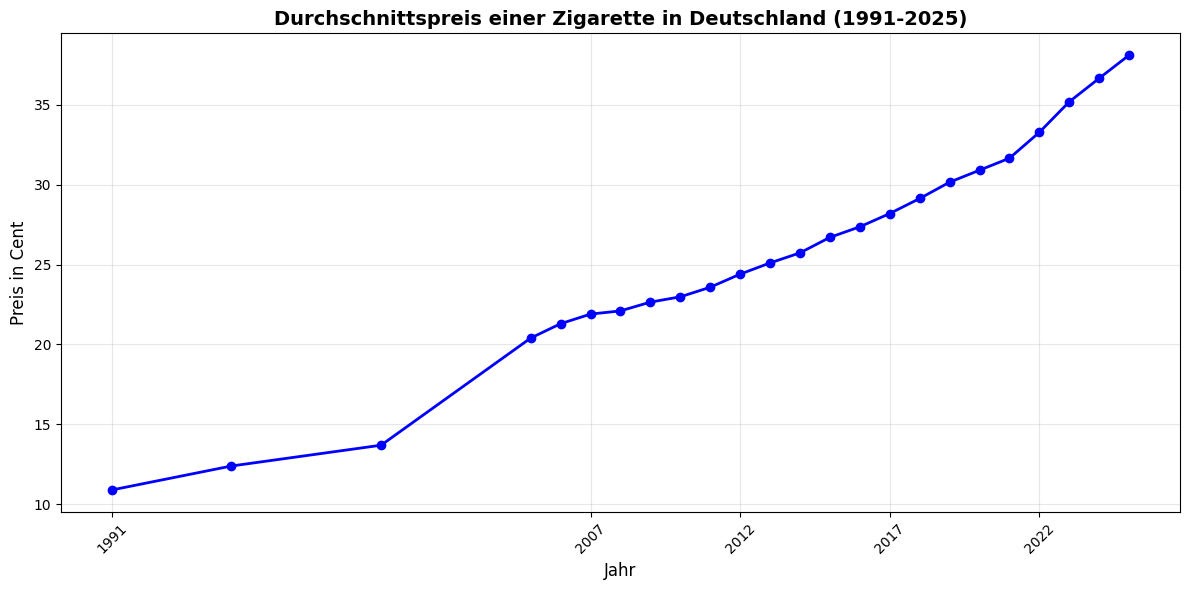

✓ Gespeichert: Grafiken/preis_pro_zigarette.png


In [16]:
import matplotlib.pyplot as plt

# Für Jupyter Notebook
%matplotlib inline

plt.figure(figsize=(12, 6))
plt.plot(jahre_zig, preis_zig_cent, marker='o', linewidth=2, markersize=6, color='blue')
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('Preis in Cent', fontsize=12)
plt.title('Durchschnittspreis einer Zigarette in Deutschland (1991-2025)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(jahre_zig[::5], rotation=45)
plt.tight_layout()
plt.savefig('Grafiken/preis_pro_zigarette.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gespeichert: Grafiken/preis_pro_zigarette.png")

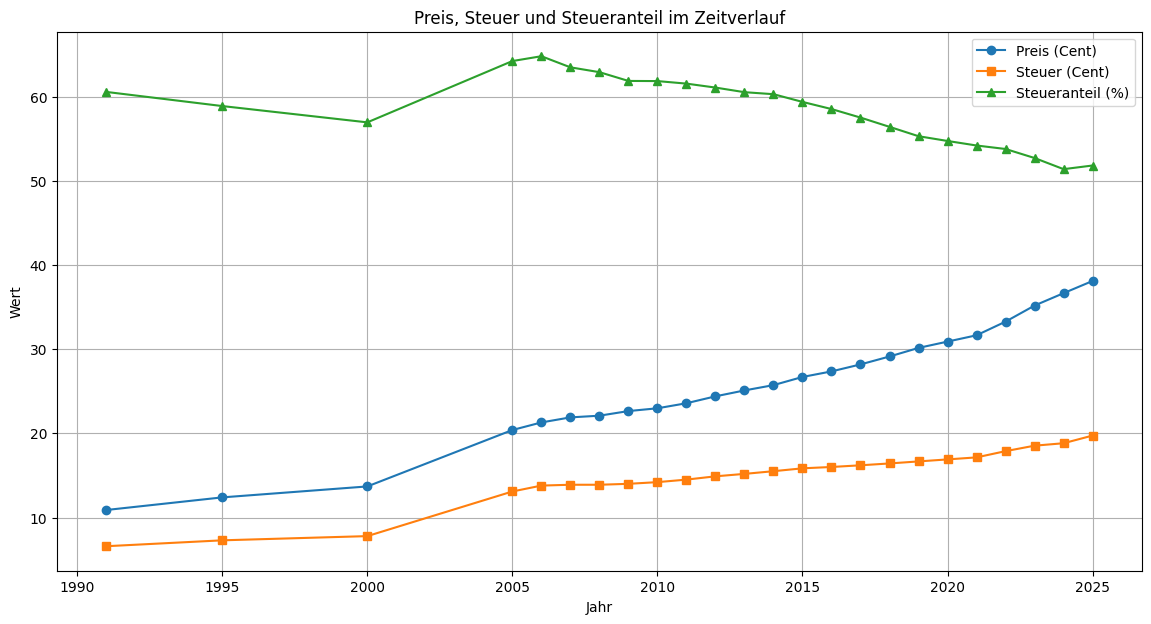

In [17]:
plt.figure(figsize=(14, 7))

plt.plot(jahre_zig, preis_zig_cent, label='Preis (Cent)', marker='o')
plt.plot(jahre_zig, steuer_zig_cent, label='Steuer (Cent)', marker='s')
plt.plot(jahre_zig, steueranteil_prozent, label='Steueranteil (%)', marker='^')

plt.xlabel('Jahr')
plt.ylabel('Wert')
plt.title('Preis, Steuer und Steueranteil im Zeitverlauf')

plt.legend()
plt.grid(True)

plt.show()

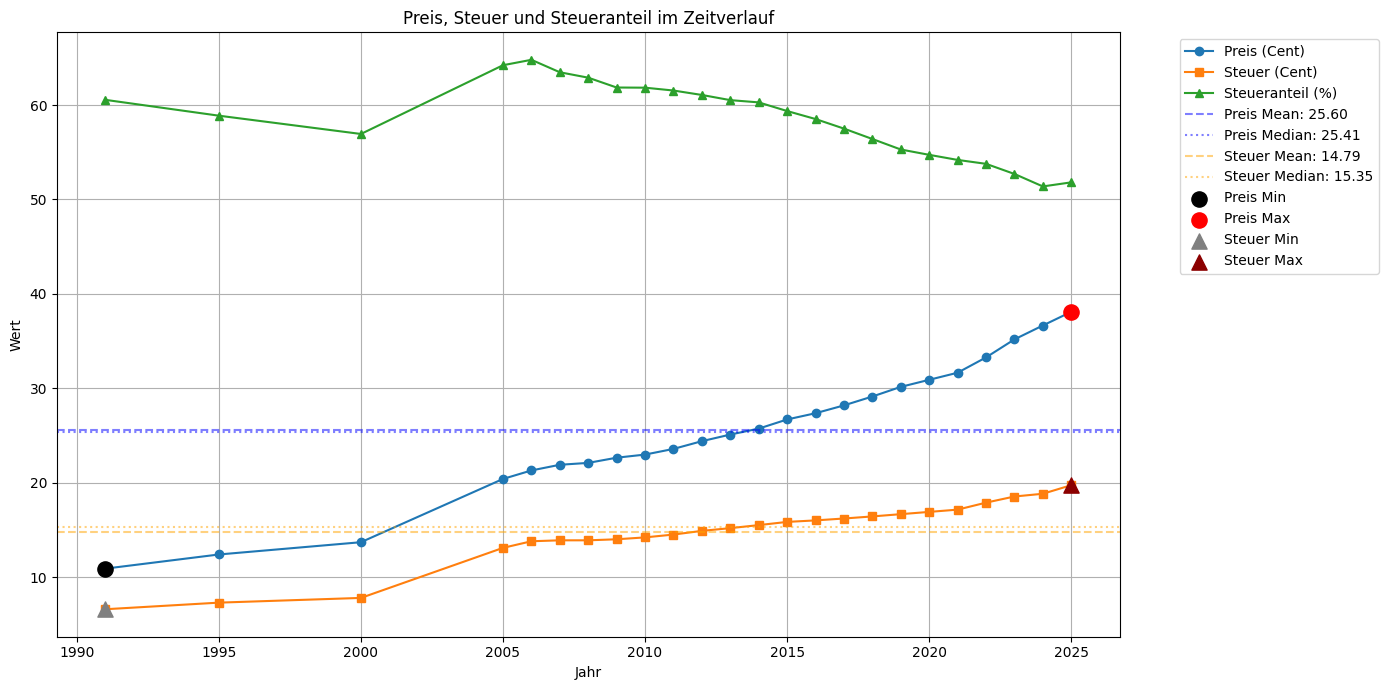

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 7))

# Grundlinien
plt.plot(jahre_zig, preis_zig_cent, label='Preis (Cent)', marker='o')
plt.plot(jahre_zig, steuer_zig_cent, label='Steuer (Cent)', marker='s')
plt.plot(jahre_zig, steueranteil_prozent, label='Steueranteil (%)', marker='^')

# Statistik für Preis
mean_preis = np.mean(preis_zig_cent)
median_preis = np.median(preis_zig_cent)

plt.axhline(
    mean_preis,
    linestyle='--',
    alpha=0.5,
    color='blue',
    label=f'Preis Mean: {mean_preis:.2f}'
)

plt.axhline(
    median_preis,
    linestyle=':',
    alpha=0.5,
    color='blue',
    label=f'Preis Median: {median_preis:.2f}'
)

# Statistik für Steuer
mean_steuer = np.mean(steuer_zig_cent)
median_steuer = np.median(steuer_zig_cent)

plt.axhline(
    mean_steuer,
    linestyle='--',
    alpha=0.5,
    color='orange',
    label=f'Steuer Mean: {mean_steuer:.2f}'
)

plt.axhline(
    median_steuer,
    linestyle=':',
    alpha=0.5,
    color='orange',
    label=f'Steuer Median: {median_steuer:.2f}'
)

# Minimum und Maximum für Preis
min_preis_index = np.argmin(preis_zig_cent)
max_preis_index = np.argmax(preis_zig_cent)

plt.scatter(
    jahre_zig[min_preis_index],
    preis_zig_cent[min_preis_index],
    color='black',
    s=120,
    zorder=5,
    label='Preis Min'
)

plt.scatter(
    jahre_zig[max_preis_index],
    preis_zig_cent[max_preis_index],
    color='red',
    s=120,
    zorder=5,
    label='Preis Max'
)

# Minimum und Maximum für Steuer
min_steuer_index = np.argmin(steuer_zig_cent)
max_steuer_index = np.argmax(steuer_zig_cent)

plt.scatter(
    jahre_zig[min_steuer_index],
    steuer_zig_cent[min_steuer_index],
    color='gray',
    s=120,
    marker='^',
    zorder=5,
    label='Steuer Min'
)

plt.scatter(
    jahre_zig[max_steuer_index],
    steuer_zig_cent[max_steuer_index],
    color='darkred',
    s=120,
    marker='^',
    zorder=5,
    label='Steuer Max'
)

# Diagramm formatieren
plt.xlabel('Jahr')
plt.ylabel('Wert')
plt.title('Preis, Steuer und Steueranteil im Zeitverlauf')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()